In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import torch
from nanodrz.model import DiarizeGPT, Config
from nanodrz.data import libritts_test, artificial_diarisation_sample
from nanodrz.utils import visualise_annotation, play
from nanodrz.download import dl_scp_file
from nanodrz import format_conversions as format

ckpt = torch.load(dl_scp_file("gpudev:/home/harry/storj/runs/nanodrz/1706615262/0004500.pt"))

rsync --partial --progress --human-readable -e ssh gpudev:/home/harry/storj/runs/nanodrz/1706615262/0004500.pt /home/harry/storj/runs/nanodrz/1706615262/0004500.pt
0004500.pt

              0   0%    0.00kB/s    0:00:00  
          7.05M   0%    6.69MB/s    0:03:02  
         16.78M   1%    7.99MB/s    0:02:31  
         37.00M   2%   11.71MB/s    0:01:41  
         58.39M   4%   13.88MB/s    0:01:24  
         79.50M   6%   17.23MB/s    0:01:06  
         99.94M   7%   19.77MB/s    0:00:57  
        119.24M   9%   19.55MB/s    0:00:56  
        139.00M  11%   19.14MB/s    0:00:57  
        156.01M  12%   18.14MB/s    0:00:59  
        173.11M  13%   17.36MB/s    0:01:01  
        192.58M  15%   17.44MB/s    0:00:59  
        212.89M  16%   17.60MB/s    0:00:57  
        233.05M  18%   18.37MB/s    0:00:54  
        254.94M  20%   19.49MB/s    0:00:50  
        269.29M  21%   18.28MB/s    0:00:52  
        287.87M  22%   17.85MB/s    0:00:53  
        306.12M  24%   17.40MB/s    0:00:5

In [3]:
config = Config(**ckpt["config"])
model:DiarizeGPT = DiarizeGPT.from_pretrained(ckpt).cuda()

/home/harry/diarisation/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


[0.1729106605052948, 4.236310958862305, 'A']
[4.322766304016113, 8.213255882263184, 'B']
[8.3861665725708, 17.031700134277344, 'A']
[17.550432205200195, 17.636886596679688, 'B']
[17.636886596679688, 18.15561866760254, 'C']
[18.5878963470459, 18.847261428833008, 'B']
[18.847261428833008, 19.711814880371094, 'A']


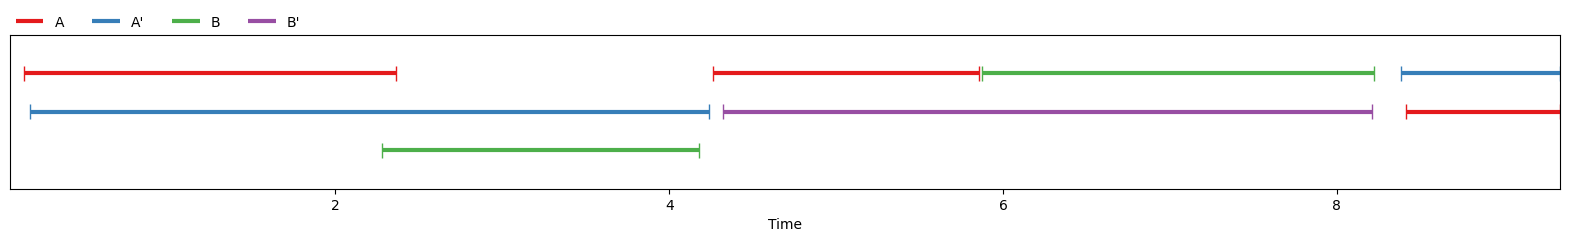

0.4847672968136474

In [22]:
# Use the same parameters that the model was trained on to generate a sample
audio, labels = artificial_diarisation_sample(libritts_test(),num_speakers=4)
reference = format.labels_to_annotation(labels)
play(audio)


# Build the prompt version as the model could be choosing different speakers

nlabels = model.generate(audio.cuda(), temperature=1, max_steps=(len(labels))*3, top_p=.5)
print("\n".join([str(n) for n in nlabels]))

for l in nlabels:
    l[2] = l[2]+ "'"

hypothesis = format.labels_to_annotation(nlabels)
visualise_annotation(labels+nlabels)

from pyannote.core import Annotation
from pyannote.metrics.diarization import DiarizationErrorRate

metric = DiarizationErrorRate()
metric(reference, hypothesis)

### Calculate Metrics with Pyannote


0.9954812756957068